# Scarlet2 Source Detection Notebook
This notebook mirrors the original `sliced.ipynb` workflow, but reads the cube from HDF5 and uses scarlet2 wavelet detection.

Because the HDF5 cube does not include a FITS WCS header, the plots are shown in pixel coordinates.

In [34]:
import numpy as np
import h5py
import matplotlib
import matplotlib.pyplot as plt
import scarlet2 as sc
from scipy.ndimage import gaussian_filter
from skimage.measure import label, regionprops
from skimage.feature import peak_local_max

plt.rcParams["figure.figsize"] = (8, 6)
matplotlib.rc('image', interpolation='none', origin='lower')
matplotlib.rc('grid', linestyle='-', linewidth=0.5, color='gray', alpha=0.5)

Loaded cube shape: (64, 96, 96)
Loaded 64 channel velocities
Expecting 4 sources from HDF5 galaxies/cubes


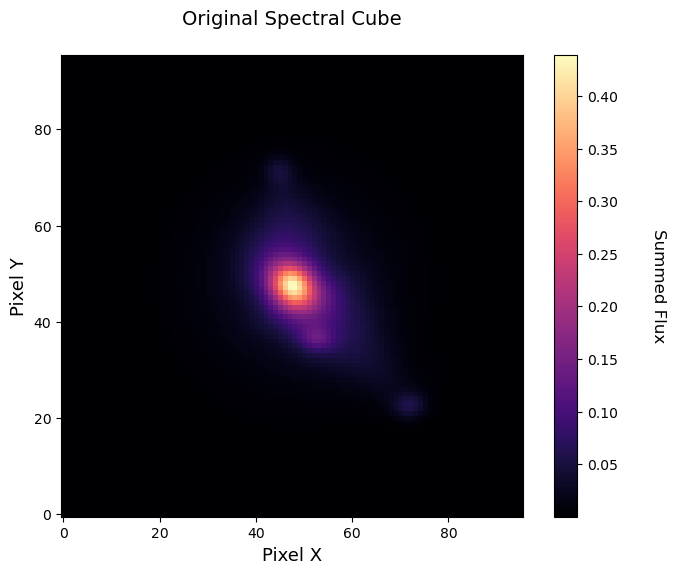

In [35]:
cube_path = '/Users/arnablahiry/repos/GalCubeCraft-SourceID/experiments/sep_v1/data/cube_188.h5'

with h5py.File(cube_path, 'r') as f:
    cube = f['cube'][...].astype(np.float32)
    velocities = f['channel_velocities_km_s'][...].astype(np.float32)
    galaxy_cubes = f['galaxies/cubes'][...].astype(np.float32)
    galaxy_positions = f['galaxies/positions_xyz_px'][...]

S, N, M = cube.shape
n_sources = int(galaxy_cubes.shape[0])
print(f'Loaded cube shape: {cube.shape}')
print(f'Loaded {len(velocities)} channel velocities')
print(f'Expecting {n_sources} sources from HDF5 galaxies/cubes')

fig = plt.figure(figsize=(8, 6))
plt.title('Original Spectral Cube\n', fontsize=14)
plt.imshow(np.sum(cube, axis=0), cmap='magma')
cbar = plt.colorbar()
cbar.set_label('Summed Flux', rotation=270, labelpad=35, fontsize=12)
plt.xlabel('Pixel X', fontsize=13)
plt.ylabel('Pixel Y', fontsize=13)
plt.show()

In [36]:
def crop_cube_array(cube, ylims, xlims, zlims=None):
    if zlims is not None:
        z0, z1 = zlims
    else:
        z0, z1 = 0, cube.shape[0]

    y0, y1 = ylims
    x0, x1 = xlims
    return cube[z0:z1, y0:y1, x0:x1]

xlims = (0, 0)
ylims = (0, 0)
zlims = None

cropped_cube = cube #crop_cube_array(cube, ylims=ylims, xlims=xlims, zlims=zlims)
cropped_velocities = velocities if zlims is None else velocities[zlims[0]:zlims[1]]

print('Cropped cube shape:', cropped_cube.shape)
print('Velocity range:', cropped_velocities[0], 'to', cropped_velocities[-1])

Cropped cube shape: (64, 96, 96)
Velocity range: -590.625 to 590.625


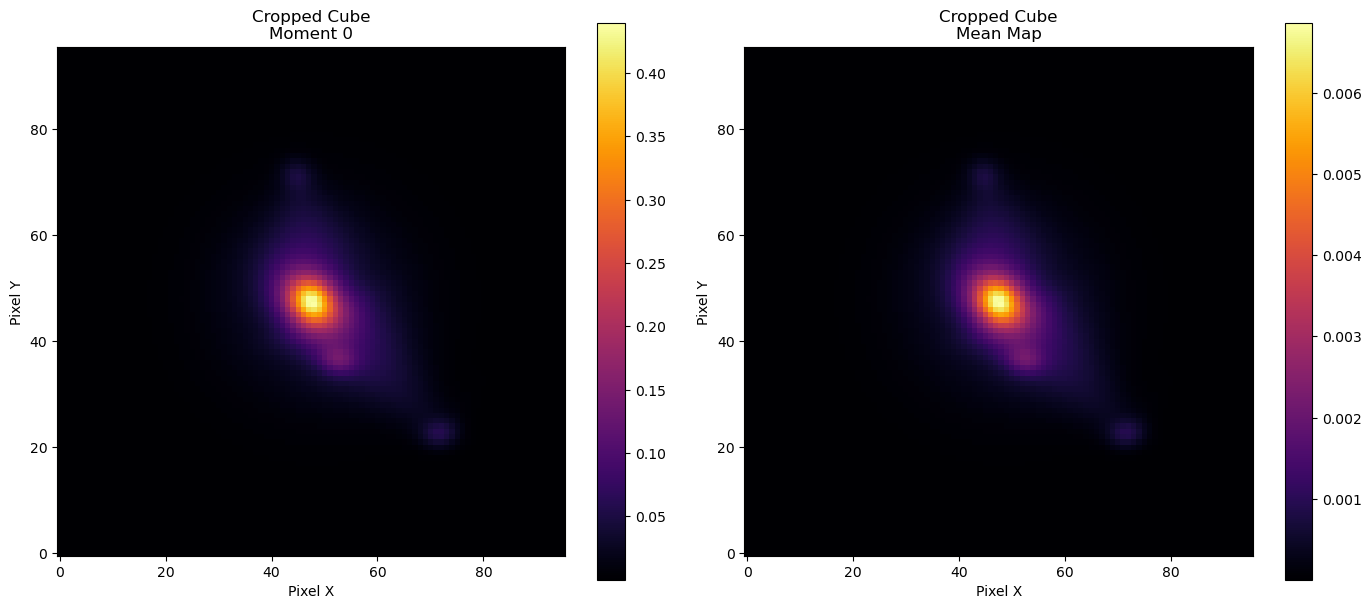

In [37]:
data = np.asarray(cropped_cube)
np.save('/Users/arnablahiry/Desktop/cube_data.npy', data)

moment0_map = np.sum(cropped_cube, axis=0)
mean_map = np.mean(cropped_cube, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im0 = axes[0].imshow(moment0_map, cmap='inferno')
axes[0].set_title('Cropped Cube\nMoment 0')
axes[0].set_xlabel('Pixel X')
axes[0].set_ylabel('Pixel Y')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(mean_map, cmap='inferno')
axes[1].set_title('Cropped Cube\nMean Map')
axes[1].set_xlabel('Pixel X')
axes[1].set_ylabel('Pixel Y')
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

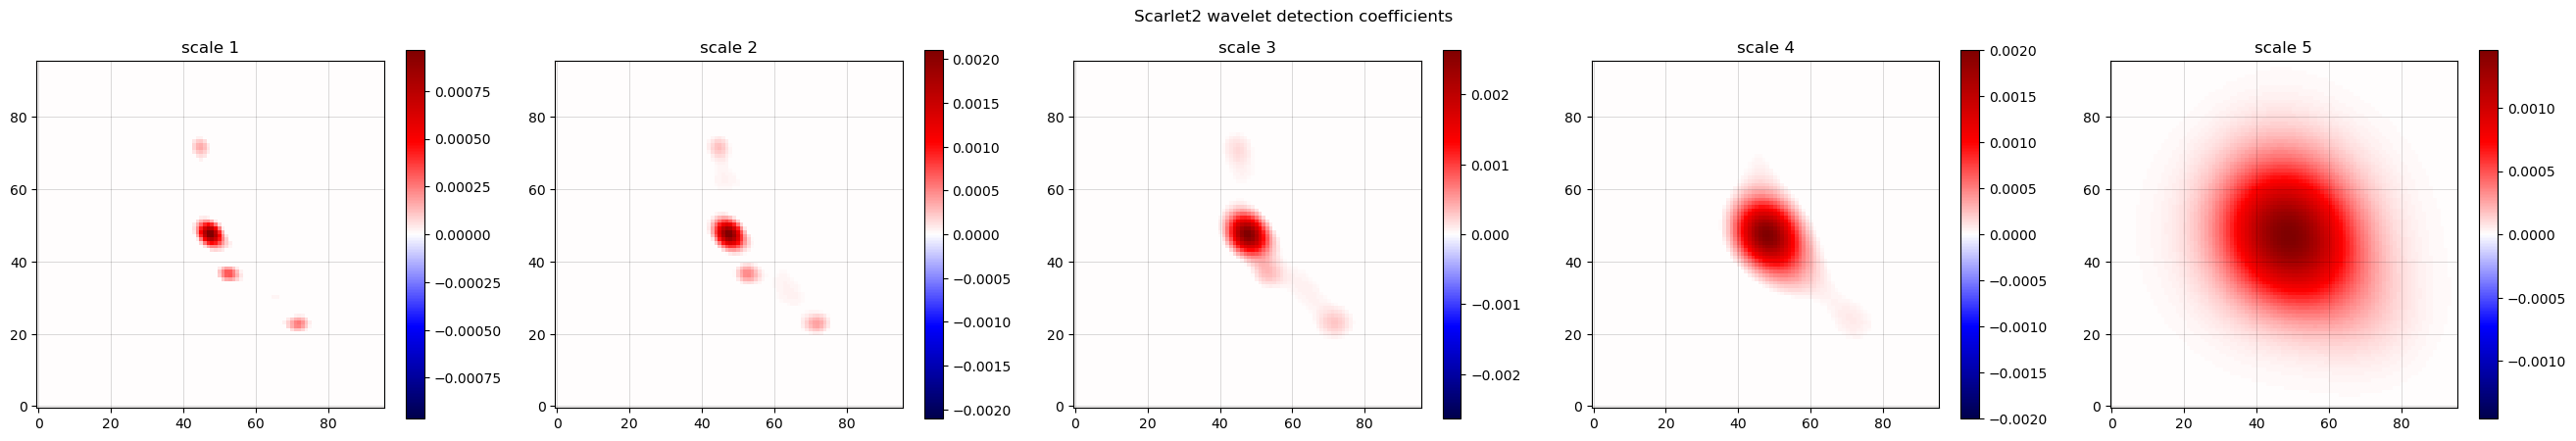

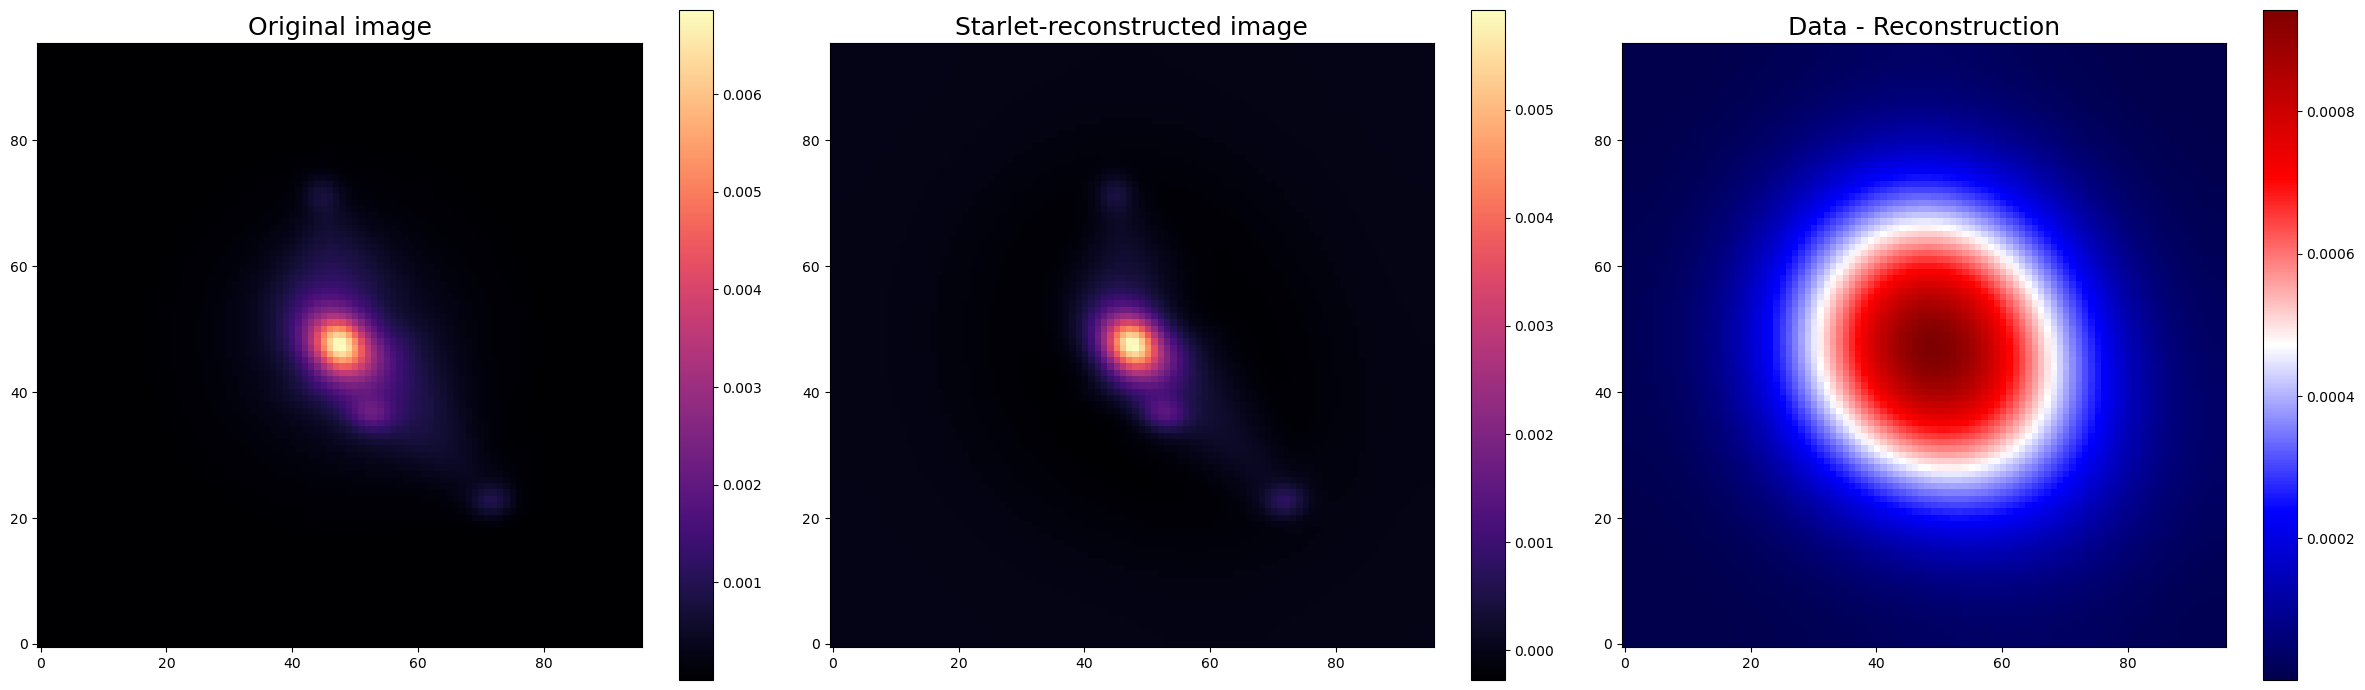

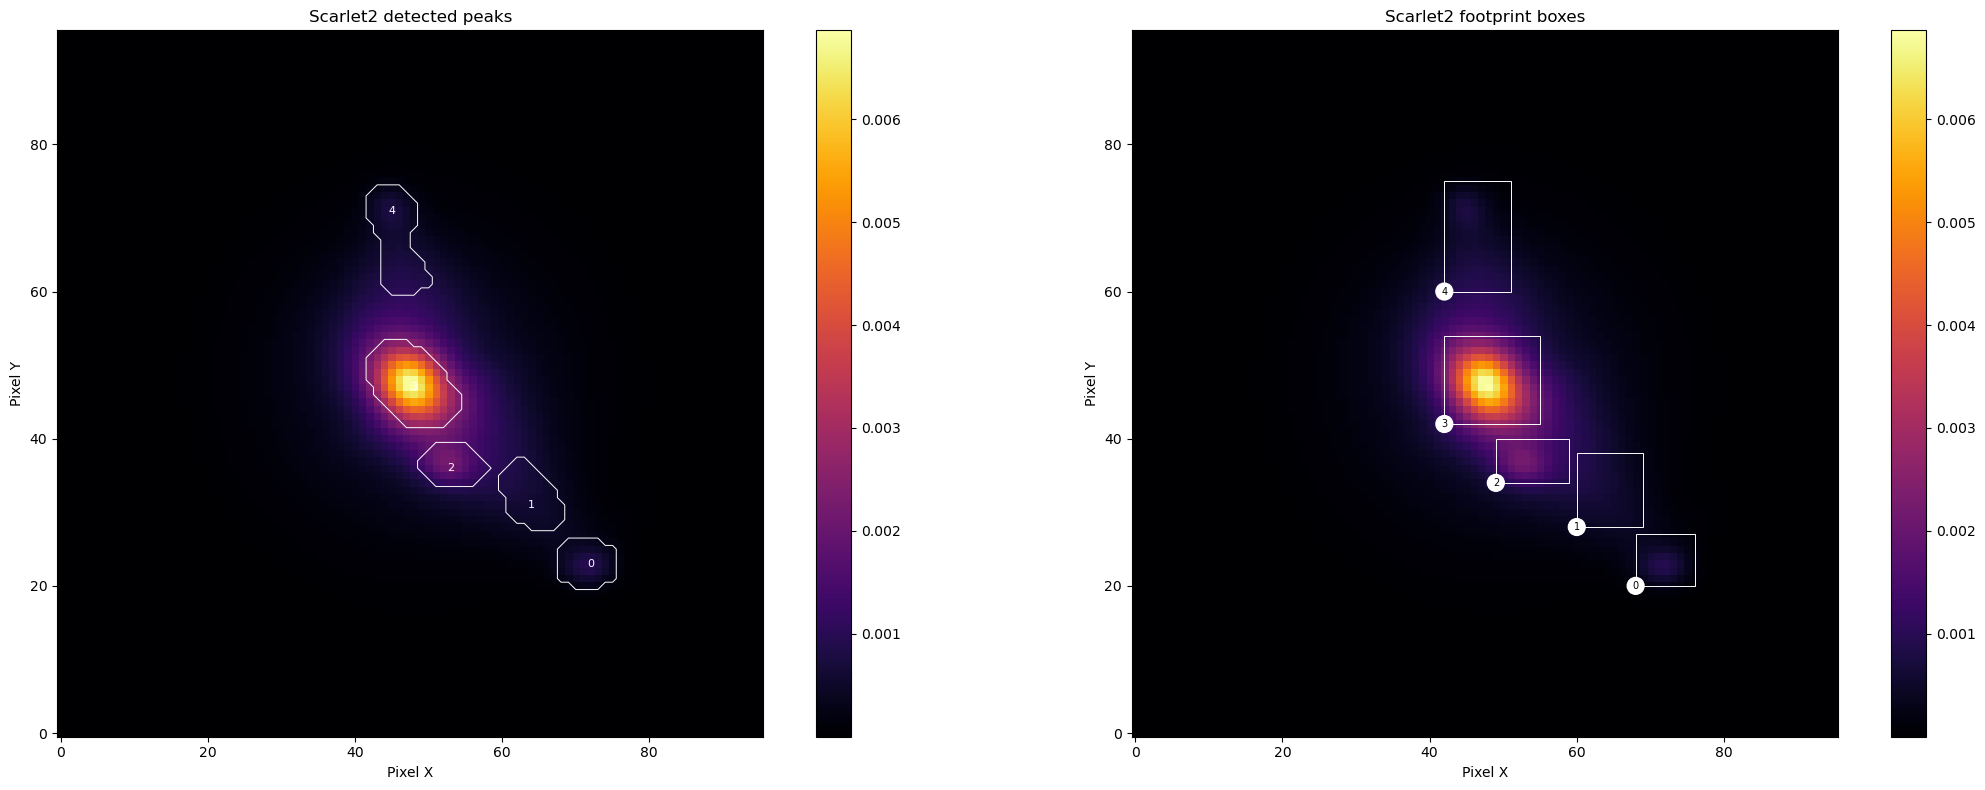

In [38]:
def wavelet_footprints_scarlet2(image, scales=4, k_sigma=2.3, use_scale=2, min_area=10, thresh=0.0):
    img = np.asarray(image, dtype=np.float32)
    sigma = 1.4826 * np.median(np.abs(img - np.median(img))) + 1e-8
    coeffs = np.asarray(sc.wavelets.starlet_transform(img, scales=scales), dtype=np.float32)

    detect = np.zeros_like(coeffs)
    for i in range(coeffs.shape[0] - 1):
        detect[i] = np.where(np.abs(coeffs[i]) > (k_sigma * sigma), coeffs[i], 0.0)
    detect[-1] = coeffs[-1]
    detect[detect < 0] = 0

    scale_idx = int(np.clip(use_scale - 1, 0, detect.shape[0] - 1))
    plane = detect[scale_idx]
    binary = plane > max(thresh, 0.0)
    labeled = label(binary)
    regions = [r for r in regionprops(labeled, intensity_image=plane) if r.area >= min_area]

    peaks = []
    footprint_masks = []
    boxes = []
    for r in regions:
        y0, x0, y1, x1 = r.bbox
        patch = plane[y0:y1, x0:x1]
        if patch.size == 0:
            continue
        py, px = np.unravel_index(np.argmax(patch), patch.shape)
        yy = y0 + py
        xx = x0 + px
        peaks.append((yy, xx))
        footprint_masks.append(labeled == r.label)
        boxes.append((y0, x0, y1, x1))

    if len(peaks) == 0:
        fallback = peak_local_max(img, min_distance=3, num_peaks=1, exclude_border=False)
        if len(fallback) > 0:
            yy, xx = fallback[0]
            peaks = [(int(yy), int(xx))]
            mask = np.zeros_like(img, dtype=bool)
            y0 = max(0, int(yy) - 2)
            y1 = min(img.shape[0], int(yy) + 3)
            x0 = max(0, int(xx) - 2)
            x1 = min(img.shape[1], int(xx) + 3)
            mask[y0:y1, x0:x1] = True
            footprint_masks = [mask]
            boxes = [(y0, x0, y1, x1)]

    footprint_img = np.zeros_like(img, dtype=np.float32)
    for mask in footprint_masks:
        footprint_img = np.maximum(footprint_img, mask.astype(np.float32))

    return detect, coeffs, footprint_img, footprint_masks, peaks, boxes


detect_image = mean_map

detect, coeffs, footprint_img, footprint_masks, peaks, boxes = wavelet_footprints_scarlet2(
    detect_image,
    scales=4,
    k_sigma=2.3,
    use_scale=2,
    min_area=10,
    thresh=0.0,
)

lvl = detect.shape[0]
plt.figure(figsize=(lvl * 4.5 + 4, 4.5))
plt.suptitle('Scarlet2 wavelet detection coefficients')
for i in range(lvl):
    plt.subplot(1, lvl, i + 1)
    plt.title('scale ' + str(i + 1))
    img = np.arcsinh(10 * detect[i]) / 10
    vmax = np.max(np.abs(img)) if np.max(np.abs(img)) > 0 else 1.0
    plt.imshow(img, cmap='seismic', vmin=-vmax, vmax=vmax)
    plt.colorbar()
    plt.grid(color='black', linewidth=0.5, alpha=0.2)
plt.tight_layout()
plt.show()

reconstruction = sc.wavelets.starlet_reconstruction(coeffs)
residual = detect_image - reconstruction

plt.figure(figsize=(24, 7))
plt.subplot(131)
plt.title('Original image', fontsize=18)
plt.imshow(detect_image, cmap='magma')
plt.colorbar()
plt.subplot(132)
plt.title('Starlet-reconstructed image', fontsize=18)
plt.imshow(reconstruction, cmap='magma')
plt.colorbar()
plt.subplot(133)
plt.title('Data - Reconstruction', fontsize=18)
plt.imshow(residual, cmap='seismic')
plt.colorbar()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(22, 8))
im0 = ax[0].imshow(detect_image, cmap='inferno')
fig.colorbar(im0, ax=ax[0])
for mask in footprint_masks:
    ax[0].contour(mask.astype(float), [0.5], colors='w', linewidths=0.7)
for k, (yy, xx) in enumerate(peaks):
    ax[0].text(xx, yy, str(k), color='w', ha='center', va='center', size=8)
ax[0].set_title('Scarlet2 detected peaks')
ax[0].set_xlabel('Pixel X')
ax[0].set_ylabel('Pixel Y')

im1 = ax[1].imshow(detect_image, cmap='inferno')
fig.colorbar(im1, ax=ax[1])
for k, (y0, x0, y1, x1) in enumerate(boxes):
    rect = matplotlib.patches.Rectangle((x0, y0), x1 - x0, y1 - y0, linewidth=0.7, edgecolor='white', facecolor='none')
    ax[1].add_patch(rect)
    ax[1].text(x0, y0, k, ha='center', va='center', size=7, bbox=dict(boxstyle='circle,pad=0.35', fc='white', ec='white', lw=1))
ax[1].set_title('Scarlet2 footprint boxes')
ax[1].set_xlabel('Pixel X')
ax[1].set_ylabel('Pixel Y')
plt.tight_layout()
plt.show()

In [39]:
from scipy.optimize import linear_sum_assignment
from skimage.registration import optical_flow_ilk, optical_flow_tvl1


def compute_flow(prev_img, curr_img, fast=False):
    prev = np.asarray(prev_img, dtype=np.float32)
    curr = np.asarray(curr_img, dtype=np.float32)
    prev = (prev - prev.min()) / (prev.max() - prev.min() + 1e-8)
    curr = (curr - curr.min()) / (curr.max() - curr.min() + 1e-8)
    if fast:
        flow = optical_flow_ilk(prev, curr)
    else:
        flow = optical_flow_tvl1(prev, curr, num_warp=8, num_iter=12)
    return np.stack([flow[0], flow[1]], axis=-1)


def detect_centers_wavelet(image, scales=4, k_sigma=3.0, use_scale=2, min_area=8):
    detect, coeffs, footprint_img, footprint_masks, peaks, boxes = wavelet_footprints_scarlet2(
        image,
        scales=scales,
        k_sigma=k_sigma,
        use_scale=use_scale,
        min_area=min_area,
        thresh=0.0,
    )
    if len(peaks) == 0:
        fallback = peak_local_max(np.asarray(image, dtype=np.float32), min_distance=3, num_peaks=3, exclude_border=False)
        peaks = [(int(y), int(x)) for y, x in fallback]
        footprint_masks = []
        boxes = []
        for y, x in peaks:
            mask = np.zeros_like(image, dtype=bool)
            y0 = max(0, y - 2)
            y1 = min(image.shape[0], y + 3)
            x0 = max(0, x - 2)
            x1 = min(image.shape[1], x + 3)
            mask[y0:y1, x0:x1] = True
            footprint_masks.append(mask)
            boxes.append((y0, x0, y1, x1))
    return detect, coeffs, footprint_img, footprint_masks, peaks, boxes


def summarize_peaks(peaks, image, footprint_img):
    summary = []
    for y, x in peaks:
        summary.append({
            'centroid': (float(y), float(x)),
            'flux': float(image[int(y), int(x)]),
            'mask': np.zeros_like(image, dtype=bool),
        })
    for item in summary:
        y, x = item['centroid']
        yi = int(np.clip(round(y), 0, image.shape[0] - 1))
        xi = int(np.clip(round(x), 0, image.shape[1] - 1))
        item['mask'][max(0, yi - 1):min(image.shape[0], yi + 2), max(0, xi - 1):min(image.shape[1], xi + 2)] = True
        item['mask'] |= footprint_img > 0
    return summary


def match_tracks(prev_tracks, curr_tracks, flow, max_dist=8.0):
    active_prev = []
    inactive_prev = []
    for idx, tr in enumerate(prev_tracks):
        y, x = tr['centroid']
        if np.isfinite(y) and np.isfinite(x):
            active_prev.append((idx, tr))
        else:
            inactive_prev.append(idx)

    if len(active_prev) == 0:
        return [], list(range(len(curr_tracks))), inactive_prev
    if len(curr_tracks) == 0:
        return [], [], [idx for idx, _ in active_prev] + inactive_prev

    cost = np.full((len(active_prev), len(curr_tracks)), 1e6, dtype=np.float32)
    for row, (prev_idx, tr) in enumerate(active_prev):
        y, x = tr['centroid']
        yi = int(np.clip(round(y), 0, flow.shape[0] - 1))
        xi = int(np.clip(round(x), 0, flow.shape[1] - 1))
        pred_y = y + float(flow[yi, xi, 0])
        pred_x = x + float(flow[yi, xi, 1])
        for j, cand in enumerate(curr_tracks):
            cy, cx = cand['centroid']
            dist = np.hypot(cy - pred_y, cx - pred_x)
            cost[row, j] = dist if dist <= max_dist else 1e6

    row_ind, col_ind = linear_sum_assignment(cost)
    matches = []
    matched_prev = set()
    matched_curr = set()
    for r, c in zip(row_ind, col_ind):
        if cost[r, c] < 1e5:
            prev_idx = active_prev[r][0]
            matches.append((prev_idx, c))
            matched_prev.add(prev_idx)
            matched_curr.add(c)

    unmatched_curr = [j for j in range(len(curr_tracks)) if j not in matched_curr]
    unmatched_prev = [idx for idx, _ in active_prev if idx not in matched_prev] + inactive_prev
    return matches, unmatched_curr, unmatched_prev

In [40]:
slice_tracks = []
track_states = []

for s_idx in range(cropped_cube.shape[0]):
    slice_img = cropped_cube[s_idx]
    detect_s, coeffs_s, footprint_s, footprint_masks_s, peaks_s, boxes_s = detect_centers_wavelet(
        slice_img,
        scales=4,
        k_sigma=3.0,
        use_scale=2,
        min_area=8,
    )

    current_tracks = []
    for p_idx, (py, px) in enumerate(peaks_s):
        mask = footprint_masks_s[p_idx] if p_idx < len(footprint_masks_s) else np.zeros_like(slice_img, dtype=bool)
        current_tracks.append({
            'track_id': None,
            'slice_index': s_idx,
            'velocity_km_s': float(cropped_velocities[s_idx]),
            'centroid': (float(py), float(px)),
            'peak_value': float(slice_img[int(py), int(px)]),
            'footprint_mask': mask,
            'box': boxes_s[p_idx] if p_idx < len(boxes_s) else None,
        })

    if s_idx == 0:
        # Initialize exactly one track slot per expected source.
        base = current_tracks[:n_sources]
        if len(base) < n_sources:
            for _ in range(n_sources - len(base)):
                base.append({
                    'track_id': None,
                    'slice_index': 0,
                    'velocity_km_s': float(cropped_velocities[0]),
                    'centroid': (float('nan'), float('nan')),
                    'peak_value': 0.0,
                    'footprint_mask': np.zeros_like(slice_img, dtype=bool),
                    'box': None,
                })
        for tid, tr in enumerate(base):
            tr['track_id'] = tid
        track_states = base
        slice_tracks.append(base)
        continue

    flow = compute_flow(cropped_cube[s_idx - 1], slice_img, fast=False)
    matches, unmatched_curr, unmatched_prev = match_tracks(track_states, current_tracks, flow, max_dist=8.0)

    updated_tracks = []
    used_curr = set()
    for prev_i, curr_i in matches:
        track_id = track_states[prev_i]['track_id']
        updated = current_tracks[curr_i].copy()
        updated['track_id'] = track_id
        updated_tracks.append(updated)
        used_curr.add(curr_i)

    # Keep track slots fixed: unmatched previous tracks are propagated forward if needed.
    for prev_i in unmatched_prev:
        prev_track = track_states[prev_i].copy()
        prev_track['slice_index'] = s_idx
        prev_track['velocity_km_s'] = float(cropped_velocities[s_idx])
        updated_tracks.append(prev_track)

    # If we still have fewer than n_sources slots, fill from unmatched current detections.
    for curr_i in unmatched_curr:
        if len(updated_tracks) >= n_sources:
            break
        updated = current_tracks[curr_i].copy()
        updated['track_id'] = track_states[len(updated_tracks)]['track_id'] if len(updated_tracks) < len(track_states) else len(updated_tracks)
        updated_tracks.append(updated)
        used_curr.add(curr_i)

    # Enforce exactly n_sources tracks.
    if len(updated_tracks) > n_sources:
        updated_tracks = updated_tracks[:n_sources]
    elif len(updated_tracks) < n_sources:
        for tid in range(len(updated_tracks), n_sources):
            updated_tracks.append({
                'track_id': tid,
                'slice_index': s_idx,
                'velocity_km_s': float(cropped_velocities[s_idx]),
                'centroid': (float('nan'), float('nan')),
                'peak_value': 0.0,
                'footprint_mask': np.zeros_like(slice_img, dtype=bool),
                'box': None,
            })

    # Re-label to guarantee stable 0..n_sources-1 track ids.
    for tid, tr in enumerate(updated_tracks[:n_sources]):
        tr['track_id'] = tid

    slice_tracks.append(updated_tracks[:n_sources])
    track_states = updated_tracks[:n_sources]

print(f'Built exactly {n_sources} fixed tracks across {cropped_cube.shape[0]} velocity channels')
for tr in slice_tracks[:3]:
    print(tr[:2] if len(tr) > 2 else tr)

Built exactly 4 fixed tracks across 64 velocity channels
[{'track_id': 0, 'slice_index': 0, 'velocity_km_s': -590.625, 'centroid': (nan, nan), 'peak_value': 0.0, 'footprint_mask': array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]], shape=(96, 96)), 'box': None}, {'track_id': 1, 'slice_index': 0, 'velocity_km_s': -590.625, 'centroid': (nan, nan), 'peak_value': 0.0, 'footprint_mask': array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, Fals

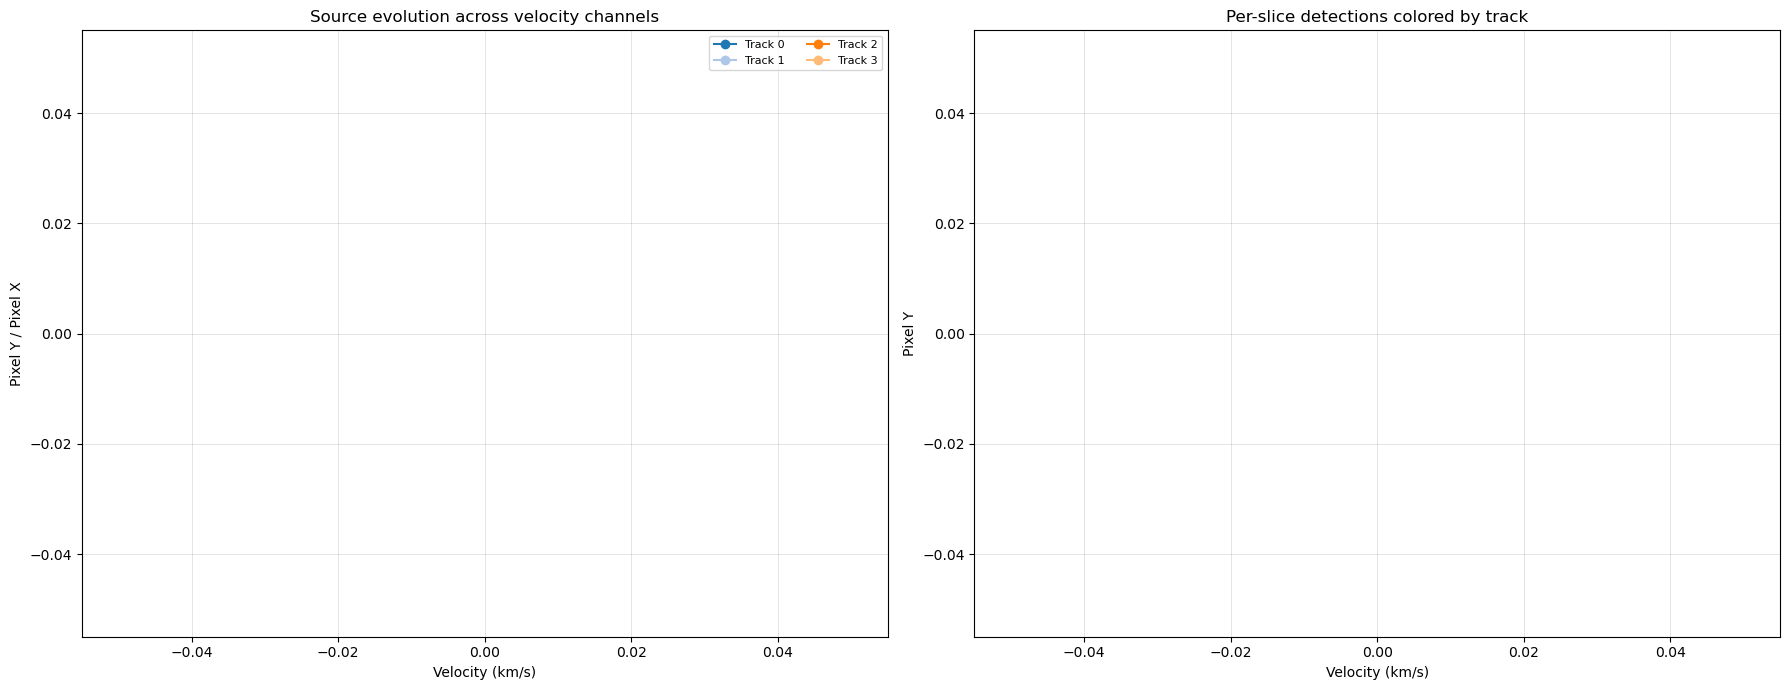

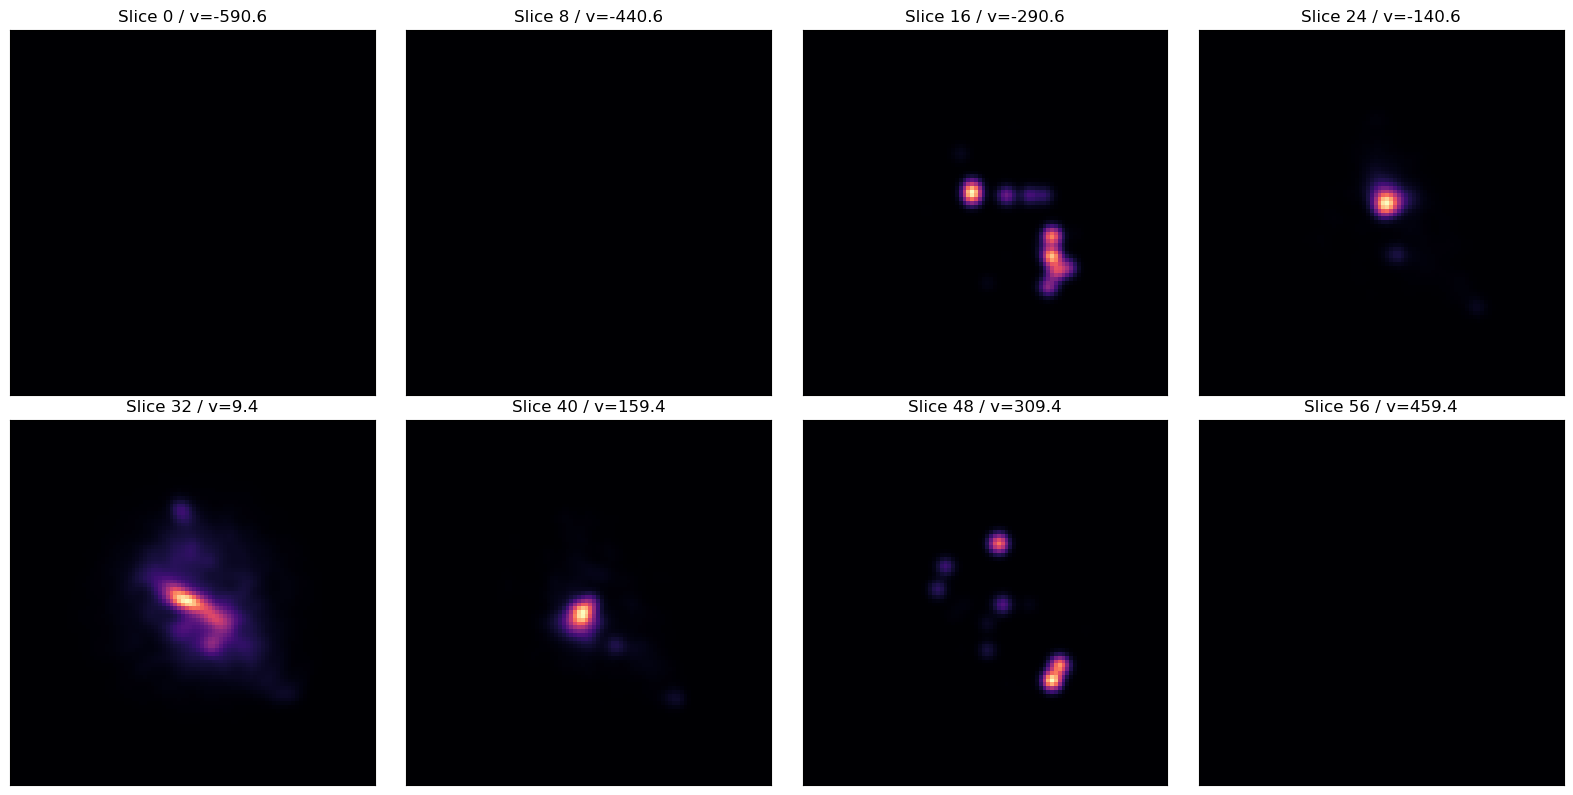

In [41]:
track_rows = []
for slice_group in slice_tracks:
    for item in slice_group:
        track_rows.append(item)

if len(track_rows) == 0:
    raise RuntimeError('No slice-wise tracks were detected')

track_ids = sorted({row['track_id'] for row in track_rows})
track_colors = {tid: plt.get_cmap('tab20')(i % 20) for i, tid in enumerate(track_ids)}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: track evolution across velocity channels.
for tid in track_ids:
    rows = [r for r in track_rows if r['track_id'] == tid]
    rows = sorted(rows, key=lambda r: r['slice_index'])
    if len(rows) < 2:
        continue
    vel = [r['velocity_km_s'] for r in rows]
    yy = [r['centroid'][0] for r in rows]
    xx = [r['centroid'][1] for r in rows]
    axes[0].plot(vel, yy, marker='o', lw=1.5, color=track_colors[tid], label=f'Track {tid}')
    axes[0].plot(vel, xx, marker='x', lw=1.0, color=track_colors[tid], alpha=0.55)

axes[0].set_title('Source evolution across velocity channels')
axes[0].set_xlabel('Velocity (km/s)')
axes[0].set_ylabel('Pixel Y / Pixel X')
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='best', fontsize=8, ncol=2)

# Right: track locations per velocity channel.
for tid in track_ids:
    rows = [r for r in track_rows if r['track_id'] == tid]
    rows = sorted(rows, key=lambda r: r['slice_index'])
    if len(rows) < 1:
        continue
    vel = [r['velocity_km_s'] for r in rows]
    yy = [r['centroid'][0] for r in rows]
    axes[1].scatter(vel, yy, s=18, color=track_colors[tid], label=f'Track {tid}')

axes[1].set_title('Per-slice detections colored by track')
axes[1].set_xlabel('Velocity (km/s)')
axes[1].set_ylabel('Pixel Y')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Optional slice grid with actual footprint mask contours for visual inspection.
step = max(1, cropped_cube.shape[0] // 8)
show_slices = list(range(0, cropped_cube.shape[0], step))[:8]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()
for ax, s_idx in zip(axes, show_slices):
    ax.imshow(cropped_cube[s_idx], cmap='magma')
    ax.set_title(f'Slice {s_idx} / v={cropped_velocities[s_idx]:.1f}')
    for item in slice_tracks[s_idx]:
        y, x = item['centroid']
        tid = item['track_id']
        mask = item['footprint_mask']
        if mask is not None and np.any(mask):
            ax.contour(mask.astype(float), [0.5], colors=[track_colors[tid]], linewidths=0.8)
        ax.plot(x, y, 'o', ms=4, color=track_colors[tid])
        ax.text(x + 1, y + 1, str(tid), color='white', fontsize=7)
    ax.set_xticks([])
    ax.set_yticks([])

for ax in axes[len(show_slices):]:
    ax.axis('off')

plt.tight_layout()
plt.show()